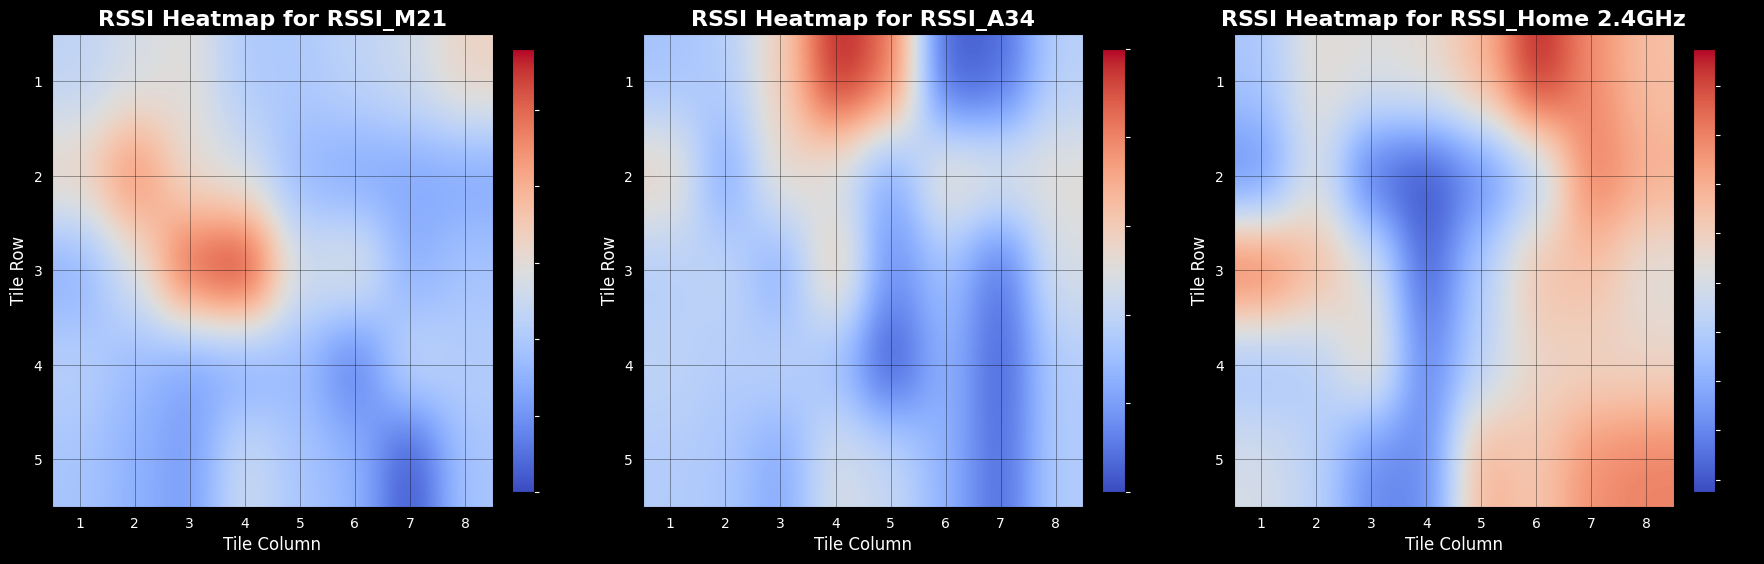

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Load the scan1 data from the CSV file
try:
    data = pd.read_csv('data/Scan1.txt')
except FileNotFoundError:
    print("Error: The file 'data/Scan1.txt' was not found.")
    exit()

# 2.  Handle the repeated tile entries by averaging
averaged_data = []
for i in range(0, len(data), 2):
    row1 = data.iloc[i]
    row2 = data.iloc[i + 1]
    avg_row = {
        'Tile': row1['Tile'],
        'RSSI_M21': (row1['RSSI_M21'] + row2['RSSI_M21']) / 2,
        "RSSI_A34": (row1["RSSI_Alok's A34"] + row2["RSSI_Alok's A34"]) / 2,
        'RSSI_Home 2.4GHz': (row1['RSSI_Home 2.4GHz'] + row2['RSSI_Home 2.4GHz']) / 2,
    }
    averaged_data.append(avg_row)
averaged_df = pd.DataFrame(averaged_data)

# 3. Create Enhanced Heatmaps with Coolwarm Colormap
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
access_points = ['RSSI_M21', "RSSI_A34", 'RSSI_Home 2.4GHz']

for i, ap in enumerate(access_points):
    # Create a 2D grid to represent the hall (5 rows, 8 columns)
    heatmap_data = np.zeros((5, 8))
    for index, row in averaged_df.iterrows():
        row_index = (int(row['Tile']) - 1) // 8
        col_index = (int(row['Tile']) - 1) % 8
        heatmap_data[row_index, col_index] = row[ap]

    # Enhanced Visuals with coolwarm colormap
    im = axes[i].imshow(heatmap_data, cmap='coolwarm', aspect='auto', interpolation='gaussian')  # Changed cmap to 'coolwarm'
    axes[i].set_title(f"RSSI Heatmap for {ap}", fontsize=16, fontweight='bold', color='white')
    axes[i].set_xlabel("Tile Column", fontsize=12, color='white')
    axes[i].set_ylabel("Tile Row", fontsize=12, color='white')

    # Customize Ticks and Labels
    axes[i].set_xticks(np.arange(8))
    axes[i].set_yticks(np.arange(5))
    axes[i].set_xticklabels(np.arange(1, 9), color='white')
    axes[i].set_yticklabels(np.arange(1, 6), color='white')

    # Add Colorbar (for intensity reference)
    cbar = fig.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)
    cbar.ax.yaxis.set_tick_params(color='white')
    cbar.ax.yaxis.label.set_color('white')

    # Add Gridlines (optional, but can enhance clarity)
    axes[i].grid(color='black', linestyle='-', linewidth=0.5, alpha=0.5)

plt.tight_layout(pad=2.0)
fig.patch.set_facecolor('black')
plt.show()